In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import GridSearchCV

In [3]:
churn_data = pd.read_csv("Cleaned churn-bigml-80.csv")
churn_data.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
churn_data.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [4]:
encoder = LabelEncoder()

categorical_columns = [
    "State",
    "International plan",
    "Voice mail plan",
    "Churn"
]

for col in categorical_columns:
    churn_data[col] = encoder.fit_transform(churn_data[col])

In [5]:
churn_data.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [6]:
X = churn_data.drop("Churn", axis=1)

Y = churn_data["Churn"]

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [12]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=5000
)

log_model.fit(X_train, Y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
Y_pred = log_model.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1 Score:", f1_score(Y_test, Y_pred))

Accuracy: 0.8632958801498127
Precision: 0.6
Recall: 0.22784810126582278
F1 Score: 0.3302752293577982


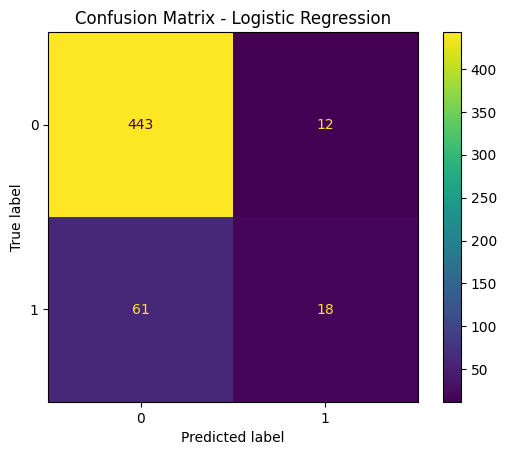

In [16]:
cm = confusion_matrix(Y_test, Y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [17]:
comparison = pd.DataFrame({
    "Actual Churn": Y_test,
    "Predicted Churn": Y_pred
})

print(comparison.head(10))

      Actual Churn  Predicted Churn
2087             1                1
1915             0                0
479              0                0
1898             1                0
741              1                0
1718             0                0
565              0                0
1037             0                0
2140             0                0
1229             0                0


In [ ]:
# Logistic Regression Conclusion

The Logistic Regression model was trained to predict customer churn using the preprocessed dataset. The model achieved an accuracy of 86.33%, indicating that it correctly classified most customers.

The precision score of 60% shows that when the model predicted a customer would churn, it was correct more than half the time. However, the recall score of 22.8% indicates that the model failed to identify many customers who actually churned. This resulted in a relatively low F1-score of 0.33.

Overall, the Logistic Regression model provides a good baseline for customer churn prediction, but other classification models such as Decision Tree and Random Forest may improve the detection of customers who are likely to churn.

In [18]:
from sklearn.tree import DecisionTreeClassifier

In [19]:
dt_model = DecisionTreeClassifier(random_state=42)

In [20]:
dt_model.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

In [21]:
Y_pred_dt = dt_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(Y_test, Y_pred_dt))
print("Precision:", precision_score(Y_test, Y_pred_dt))
print("Recall:", recall_score(Y_test, Y_pred_dt))
print("F1 Score:", f1_score(Y_test, Y_pred_dt))

Accuracy: 0.9026217228464419
Precision: 0.684931506849315
Recall: 0.6329113924050633
F1 Score: 0.6578947368421053


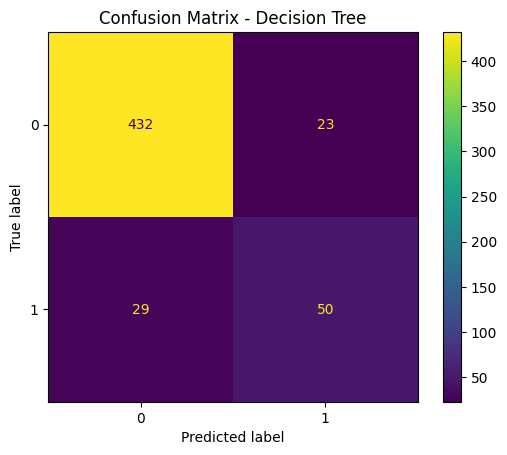

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [24]:
comparison_dt = pd.DataFrame({
    "Actual Churn": Y_test,
    "Predicted Churn": Y_pred_dt
})

comparison_dt.head(10)

,Actual Churn,Predicted Churn
2087,1,0
1915,0,0
479,0,0
1898,1,0
741,1,1
1718,0,0
565,0,0
1037,0,0
2140,0,0
1229,0,1


In [ ]:
# Decision Tree Conclusion

A Decision Tree Classifier was developed to predict customer churn. The model achieved an accuracy of 90.26%, outperforming the Logistic Regression model.

The precision score of 68.49% indicates that when the model predicted a customer would churn, it was correct most of the time. The recall score of 63.29% shows a significant improvement in identifying customers who actually churned, resulting in a higher F1-score of 65.79%.

Overall, the Decision Tree model provided better performance than Logistic Regression, making it a more suitable model for customer churn prediction on this dataset.

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [28]:
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [29]:
Y_pred_rf = rf_model.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_rf))
print("Precision:", precision_score(Y_test, Y_pred_rf))
print("Recall:", recall_score(Y_test, Y_pred_rf))
print("F1 Score:", f1_score(Y_test, Y_pred_rf))

Accuracy: 0.951310861423221
Precision: 1.0
Recall: 0.6708860759493671
F1 Score: 0.803030303030303


In [32]:
comparison_rf = pd.DataFrame({
    "Actual Churn": Y_test,
    "Predicted Churn": Y_pred_rf
})

comparison_rf.head(10)

,Actual Churn,Predicted Churn
2087,1,1
1915,0,0
479,0,0
1898,1,1
741,1,1
1718,0,0
565,0,0
1037,0,0
2140,0,0
1229,0,0


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(Y_test, Y_pred_rf)
rf_precision = precision_score(Y_test, Y_pred_rf)
rf_recall = recall_score(Y_test, Y_pred_rf)
rf_f1 = f1_score(Y_test, Y_pred_rf)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Accuracy: 0.951310861423221
Precision: 1.0
Recall: 0.6708860759493671
F1 Score: 0.803030303030303


In [36]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [0.8632958801498127, 0.9026217228464419, 0.951310861423221],
    "Precision": [0.6000000000000000, 0.684931506849315, 1.000000000000000],
    "Recall": [0.22784810126582278, 0.6329113924050633, 0.6708860759493671],
    "F1 Score": [0.3302752293577982, 0.6578947368421053, 0.803030303030303]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.863296,0.600000,0.227848,0.330275
1,Decision Tree,0.902622,0.684932,0.632911,0.657895
2,Random Forest,0.951311,1.000000,0.670886,0.803030


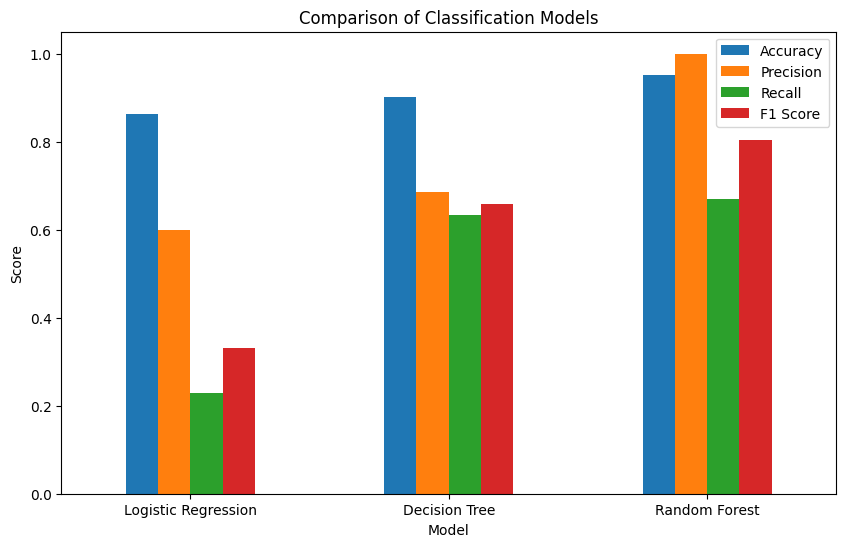

In [37]:
import matplotlib.pyplot as plt

results.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Comparison of Classification Models")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# Conclusion

In this project, three classification algorithms were implemented to predict customer churn: Logistic Regression, Decision Tree, and Random Forest.

The dataset was preprocessed by handling categorical variables, splitting the data into training and testing sets, and standardizing the numerical features before training the models.

The performance of each model was evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Among the three models, the Random Forest Classifier achieved the best overall performance with an accuracy of 95.13%, precision of 100%, recall of 67.09%, and an F1-score of 80.30%. This indicates that the model was highly effective in identifying customers who were likely to churn while minimizing incorrect predictions.

The Decision Tree also performed well and showed significant improvement over Logistic Regression, particularly in Recall and F1-score.

Logistic Regression served as a useful baseline model but had lower predictive performance, especially in identifying customers who actually churned.

Overall, Random Forest proved to be the most suitable model for customer churn prediction because it combines multiple decision trees to produce more accurate and robust predictions.